In [67]:
# Cell 1: Cài thư viện
!pip install ultralytics -q

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ultralytics import YOLO
import os, yaml, shutil

# ============================================================
# CẤU HÌNH - sửa MODEL_PATH theo đường dẫn thực tế
# ============================================================
MODEL_PATH   = "/kaggle/input/datasets/ankizsem/yolov8l-newversion/best_yolov8l_newversion.pt"
DATASET_ROOT = "/kaggle/input/datasets/ankizsem/doanai-aug/DoanAi_aug"
IMAGES_DIR   = os.path.join(DATASET_ROOT, "images")
TEST_LIST    = os.path.join(DATASET_ROOT, "split_dataset/test_files.txt")
CLASSES_FILE = os.path.join(DATASET_ROOT, "classes_en.txt")
LABELS_DIR   = os.path.join(DATASET_ROOT, "labels")

In [69]:
# ============================================================
# 1. Load model
# ============================================================
model = YOLO(MODEL_PATH)
print(f"✅ Model loaded | Classes: {model.names}")

✅ Model loaded | Classes: {0: 'Pedestrian Crossing', 1: 'Equal-level Intersection', 2: 'No Entry', 3: 'Right Turn Only', 4: 'Intersection', 5: 'Intersection with a non-priority road', 6: 'Danger zone on the left', 7: 'No Left Turn', 8: 'Bus Stop', 9: 'Roundabout', 10: 'No Stopping and No Parking', 11: 'U-Turn Allowed', 12: 'Lane Allocation', 13: 'Slow Down', 14: 'No Trucks Allowed', 15: 'Narrow Road on the Right', 16: 'Height Limit', 17: 'No U-Turn', 18: 'No Passenger Cars and Trucks', 19: 'No U-Turn and No Right Turn', 20: 'No Cars Allowed', 21: 'Narrow Road on the Left', 22: 'Uneven Road', 23: 'No Two or Three-wheeled Vehicles', 24: 'Customs Checkpoint', 25: 'Motorcycles Only', 26: 'Obstacle on the Road', 27: 'Children Present', 28: 'Trucks and Containers', 29: 'No Motorcycles Allowed', 30: 'Trucks Only', 31: 'Road with Surveillance Camera', 32: 'No Right Turn', 33: 'Double curve first to right', 34: 'No Containers Allowed', 35: 'No Left or Right Turn', 36: 'No Straight and Right Tur

In [70]:
# ============================================================
# 2. Đọc classes
# ============================================================
with open(CLASSES_FILE) as f:
    class_names = [l.strip() for l in f if l.strip()]
print(f"📋 {len(class_names)} classes: {class_names}")

📋 67 classes: ['Pedestrian Crossing', 'Equal-level Intersection', 'No Entry', 'Right Turn Only', 'Intersection', 'Intersection with a non-priority road', 'Danger zone on the left', 'No Left Turn', 'Bus Stop', 'Roundabout', 'No Stopping and No Parking', 'U-Turn Allowed', 'Lane Allocation', 'Slow Down', 'No Trucks Allowed', 'Narrow Road on the Right', 'Height Limit', 'No U-Turn', 'No Passenger Cars and Trucks', 'No U-Turn and No Right Turn', 'No Cars Allowed', 'Narrow Road on the Left', 'Uneven Road', 'No Two or Three-wheeled Vehicles', 'Customs Checkpoint', 'Motorcycles Only', 'Obstacle on the Road', 'Children Present', 'Trucks and Containers', 'No Motorcycles Allowed', 'Trucks Only', 'Road with Surveillance Camera', 'No Right Turn', 'Double curve first to right', 'No Containers Allowed', 'No Left or Right Turn', 'No Straight and Right Turn', 'Intersection with T-Junction', 'Speed limit (50km/h)', 'Speed limit (60km/h)', 'Speed limit (80km/h)', 'Speed limit (40km/h)', 'Left Turn', 'Low 

In [71]:
# ============================================================
# 3. Đọc danh sách ảnh test — FIX: stem không có extension
# ============================================================
with open(TEST_LIST) as f:
    test_stems = [l.strip() for l in f if l.strip()]

test_images, missing = [], []
for stem in test_stems:
    # Thử các extension phổ biến
    found = False
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
        full_path = os.path.join(IMAGES_DIR, stem + ext)
        if os.path.exists(full_path):
            test_images.append(full_path)
            found = True
            break
    if not found:
        missing.append(stem)

print(f"📦 Tìm thấy: {len(test_images)}/{len(test_stems)} ảnh")
if missing:
    print(f"⚠️  Thiếu {len(missing)} ảnh, ví dụ: {missing[:3]}")

📦 Tìm thấy: 1230/1230 ảnh


In [72]:
# ============================================================
# 4. Copy ảnh + label — FIX: tìm đúng extension
# ============================================================
WORK_IMG_DIR = "/kaggle/working/dataset/images"
WORK_LBL_DIR = "/kaggle/working/dataset/labels"
os.makedirs(WORK_IMG_DIR, exist_ok=True)
os.makedirs(WORK_LBL_DIR, exist_ok=True)

copied, no_label = 0, []
for stem in test_stems:
    img_src = None
    img_name = None
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
        p = os.path.join(IMAGES_DIR, stem + ext)
        if os.path.exists(p):
            img_src  = p
            img_name = stem + ext
            break
    if img_src is None:
        continue

    lbl_src = os.path.join(LABELS_DIR, stem + ".txt")
    shutil.copy2(img_src, os.path.join(WORK_IMG_DIR, img_name))

    if os.path.exists(lbl_src):
        shutil.copy2(lbl_src, os.path.join(WORK_LBL_DIR, stem + ".txt"))
        copied += 1
    else:
        no_label.append(stem)

print(f"✅ Đã copy {copied} cặp ảnh+label")
if no_label:
    print(f"⚠️  {len(no_label)} ảnh không có label: {no_label[:3]}")

✅ Đã copy 1230 cặp ảnh+label


In [73]:
# ============================================================
# 5. Tạo data.yaml chuẩn
# ============================================================
data_yaml = {
    "path": "/kaggle/working/dataset",
    "train": "images",   # placeholder, không dùng
    "val":   "images",   # placeholder, không dùng
    "test":  "images",   # YOLO scan toàn bộ thư mục images/
    "nc":    len(class_names),
    "names": class_names,
}

yaml_path = "/kaggle/working/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, allow_unicode=True)

print(f"\n✅ data.yaml tạo xong ({len(class_names)} classes)")


✅ data.yaml tạo xong (67 classes)


In [74]:
import glob
for f in glob.glob("/kaggle/working/dataset/**/*.cache", recursive=True):
    os.remove(f)
    print(f"Xóa cache: {f}")

Xóa cache: /kaggle/working/dataset/labels.cache


In [75]:
results = model.val(
    data      = yaml_path,
    split     = "test",
    imgsz     = 640,
    batch     = 16,
    conf      = 0.25,
    iou       = 0.5,
    device    = 0,
    plots     = True,
    verbose   = False,
    project   = "/kaggle/working/eval",
    name      = "test_final",   # ← đổi tên để không đọc cache cũ
    save_json = False,
)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 43,658,265 parameters, 0 gradients, 165.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2683.9±429.6 MB/s, size: 347.4 KB)
val: Scanning /kaggle/working/dataset/labels... 1230 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1230/1230 1.3Kit/s 0.9s0.0s
val: New cache created: /kaggle/working/dataset/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 77/77 2.1it/s 37.4s0.7ss
                   all       1230       3936      0.975      0.977      0.972      0.817
Speed: 0.7ms preprocess, 26.5ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/eval/test_final-5


**So với code đánh giá test của tvy sao lại khác nhau và nên dùng cái nào (code ak là code 1, code tvy là code 2)**

Vậy thì nguyên nhân duy nhất là verbose=False trong Code 2.
Khi verbose=False, Ultralytics bỏ qua một số bước tính toán trong quá trình val, dẫn đến kết quả metrics có thể khác nhẹ so với khi chạy đầy đủ.
Nên dùng Code 1 vì:

verbose mặc định = True → tính toán đầy đủ, kết quả chính xác hơn
Chỉ định rõ tất cả tham số → reproducible, phù hợp để báo cáo đồ án
Lưu plots (confusion matrix, PR curve) vào thư mục rõ ràng

Code 2 chỉ nên dùng để xem nhanh kết quả trong lúc thử nghiệm, không dùng để báo cáo chính thức.

In [76]:
# ============================================================
# 7. In kết quả
# ============================================================
print("\n========== KẾT QUẢ ĐÁNH GIÁ ==========")
print(f"mAP@0.5      : {results.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {results.box.map:.4f}")
print(f"Precision    : {results.box.mp:.4f}")
print(f"Recall       : {results.box.mr:.4f}")

print("\n--- Per-class AP@0.5 ---")
for i, name in enumerate(class_names):
    ap = results.box.ap50[i] if i < len(results.box.ap50) else float('nan')
    print(f"  {name:30s}: {ap:.4f}")

print(f"\n📁 Plots lưu tại: /kaggle/working/eval/test_run/")


========== KẾT QUẢ ĐÁNH GIÁ ==========
mAP@0.5      : 0.9715
mAP@0.5:0.95 : 0.8165
Precision    : 0.9754
Recall       : 0.9771

--- Per-class AP@0.5 ---
  Pedestrian Crossing           : 0.9850
  Equal-level Intersection      : 0.9950
  No Entry                      : 0.9432
  Right Turn Only               : 0.9641
  Intersection                  : 0.9950
  Intersection with a non-priority road: 0.9950
  Danger zone on the left       : 0.9950
  No Left Turn                  : 0.9950
  Bus Stop                      : 0.9950
  Roundabout                    : 0.9650
  No Stopping and No Parking    : 0.9935
  U-Turn Allowed                : 0.9450
  Lane Allocation               : 0.9712
  Slow Down                     : 0.9950
  No Trucks Allowed             : 0.9850
  Narrow Road on the Right      : 0.9950
  Height Limit                  : 0.9950
  No U-Turn                     : 0.9950
  No Passenger Cars and Trucks  : 0.9950
  No U-Turn and No Right Turn   : 0.9950
  No Cars Allowed  

---

In [77]:
import os
from collections import defaultdict

DATASET_ROOT = "/kaggle/input/datasets/ankizsem/doanai-aug/DoanAi_aug"
CLASSES_FILE = os.path.join(DATASET_ROOT, "classes_en.txt")
LABELS_DIR   = os.path.join(DATASET_ROOT, "labels")
SPLIT_DIR    = os.path.join(DATASET_ROOT, "split_dataset")

with open(CLASSES_FILE) as f:
    class_names = [l.strip() for l in f if l.strip()]

def count_class_stats(label_dir, file_list):
    """Đếm số ảnh và instance theo class từ danh sách file."""
    img_count  = defaultdict(int)
    inst_count = defaultdict(int)
    found = 0

    for fname in file_list:
        lbl_name = fname + ".txt"
        lbl_path = os.path.join(label_dir, lbl_name)
        if not os.path.exists(lbl_path):
            continue
        found += 1
        seen = set()
        with open(lbl_path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                cls_id = int(float(line.split()[0]))
                inst_count[cls_id] += 1
                seen.add(cls_id)
        for cls_id in seen:
            img_count[cls_id] += 1

    return img_count, inst_count, found

# Đọc 3 split
splits = {}
for split in ["train", "valid", "test"]:
    list_file = os.path.join(SPLIT_DIR, f"{split}_files.txt")
    if os.path.exists(list_file):
        with open(list_file) as f:
            splits[split] = [l.strip() for l in f if l.strip()]
    else:
        splits[split] = []
        print(f"⚠️  Không tìm thấy {list_file}")

print("📦 Số file trong mỗi split:")
for split, files in splits.items():
    print(f"   {split:5s}: {len(files)} ảnh")

# Tính stats cho từng split
stats = {}
for split, files in splits.items():
    img_c, inst_c, found = count_class_stats(LABELS_DIR, files)
    stats[split] = {"img": img_c, "inst": inst_c, "found": found}
    print(f"   {split:5s}: tìm được label của {found}/{len(files)} ảnh")

# In bảng tổng hợp
print(f"\n{'ID':>4}  {'Class':<35}", end="")
for split in ["train", "valid", "test"]:
    print(f"  {'Ảnh_'+split:>10} {'Inst_'+split:>11}", end="")
print(f"  {'Tổng_inst':>10}")
print("-" * 130)

problem_classes = []

for i, name in enumerate(class_names):
    print(f"{i:>4}  {name:<35}", end="")
    total_inst = 0
    split_data = []
    for split in ["train", "valid", "test"]:
        imgs  = stats[split]["img"].get(i, 0)
        insts = stats[split]["inst"].get(i, 0)
        total_inst += insts
        split_data.append((imgs, insts))
        print(f"  {imgs:>10} {insts:>11}", end="")
    print(f"  {total_inst:>10}")

    # Đánh dấu class có vấn đề
    test_imgs = stats["test"]["img"].get(i, 0)
    train_imgs = stats["train"]["img"].get(i, 0)
    if test_imgs == 0 and train_imgs > 0:
        problem_classes.append((i, name, train_imgs, test_imgs))

# Tóm tắt
print(f"\n{'='*130}")
for split in ["train", "valid", "test"]:
    present = sum(1 for i in range(len(class_names)) if stats[split]["img"].get(i, 0) > 0)
    total_inst = sum(stats[split]["inst"].values())
    print(f"📊 {split:5s}: {present}/{len(class_names)} classes có ảnh | {total_inst} tổng instances")

print(f"\n⚠️  Classes có trong TRAIN nhưng KHÔNG có trong TEST ({len(problem_classes)}):")
print(f"   {'ID':>4}  {'Class':<35}  {'Train_ảnh':>10}  {'Test_ảnh':>10}")
for cid, cname, tr, te in problem_classes:
    print(f"   {cid:>4}  {cname:<35}  {tr:>10}  {te:>10}")

📦 Số file trong mỗi split:
   train: 9845 ảnh
   valid: 1230 ảnh
   test : 1230 ảnh
   train: tìm được label của 9845/9845 ảnh
   valid: tìm được label của 1230/1230 ảnh
   test : tìm được label của 1230/1230 ảnh

  ID  Class                                 Ảnh_train  Inst_train   Ảnh_valid  Inst_valid    Ảnh_test   Inst_test   Tổng_inst
----------------------------------------------------------------------------------------------------------------------------------
   0  Pedestrian Crossing                         569         569          83          83          83          83         735
   1  Equal-level Intersection                    109         109          21          21          21          21         151
   2  No Entry                                    705         706         118         118         132         134         958
   3  Right Turn Only                             699         699         116         116         128         128         943
   4  Intersection       

| ID | Class | Tổng_inst trước | Tổng_inst sau | Chênh lệch |
|----|-------|-----------------|---------------|------------|
| 34 | No Containers Allowed | 82 | 82 | = 0 |
| 35 | No Left or Right Turn | 87 | 87 | = 0 |
| 52 | Green Light | 542 | 542 | = 0 |
| 53 | Red Light | 585 | 585 | = 0 |
| 55 | Speed Limit 100 | 267 | 267 | = 0 |
| 56 | Speed Limit 110 | 101 | 101 | = 0 |
| 57 | Speed Limit 120 | 252 | 252 | = 0 |
| 59 | Speed Limit 30 | 334 | 334 | = 0 |
| 60 | Speed Limit 40 | 235 | 235 | = 0 |
| 61 | Speed Limit 50 | 283 | 283 | = 0 |
| 62 | Speed Limit 60 | 301 | 301 | = 0 |
| 63 | Speed Limit 70 | 318 | 318 | = 0 |
| 64 | Speed Limit 80 | 323 | 323 | = 0 |
| 65 | Speed Limit 90 | 168 | 168 | = 0 |
| 66 | Stop | 285 | 285 | = 0 |

> Những class này giữ nguyên `Tổng_inst` vì augmentation không tạo thêm
> instance mới cho chúng — xác nhận thêm vấn đề quy trình augment đã đề cập.

In [78]:
# ============================================================
# BƯỚC 2: Per-class AP từ results.box (chuẩn YOLO)
# ============================================================
import pandas as pd
rows = []
for i, name in enumerate(class_names):
    if i >= len(results.box.ap50):
        continue
    ap50 = float(results.box.ap50[i])
    p    = float(results.box.p[i])  if i < len(results.box.p)  else float('nan')
    r    = float(results.box.r[i])  if i < len(results.box.r)  else float('nan')
    rows.append({
        "ID"      : i,
        "Class"   : name,
        "P (%)"   : round(p   * 100, 1),
        "R (%)"   : round(r   * 100, 1),
        "AP@0.5"  : round(ap50 * 100, 1),
    })
 
df = pd.DataFrame(rows).sort_values("AP@0.5", ascending=True)
 
# ── In bảng per-class ────────────────────────────────────────
print("\n" + "="*75)
print("  📊 PER-CLASS: Precision / Recall / AP@0.5")
print("="*75)
print(f"{'ID':>4}  {'Class':<40} {'P':>7} {'R':>7} {'AP@0.5':>8}")
print("-"*75)
for _, row in df.iterrows():
    ap = row["AP@0.5"]
    flag = " ⚠" if ap < 70 else ("  ✓" if ap >= 90 else "   ")
    print(f"{int(row['ID']):>4}  {row['Class']:<40} "
          f"{row['P (%)']:>6.1f}% {row['R (%)']:>6.1f}% "
          f"{ap:>7.1f}%{flag}")
 
# ── Tóm tắt ──────────────────────────────────────────────────
bad  = df[df["AP@0.5"] <  70]
mid  = df[(df["AP@0.5"] >= 70) & (df["AP@0.5"] < 90)]
good = df[df["AP@0.5"] >= 90]
 
print("="*75)
print(f"\n  ✅ Tốt  (≥90%): {len(good)} classes")
print(f"  🔶 Trung bình (70–90%): {len(mid)} classes")
print(f"  ❌ Kém  (<70%): {len(bad)} classes")
if len(bad) > 0:
    print(f"\n  ❌ Classes cần cải thiện:")
    for _, r in bad.iterrows():
        print(f"     Class {int(r['ID']):2d} | {r['Class']:<40} "
              f"| P:{r['P (%)']:>5.1f}% R:{r['R (%)']:>5.1f}% AP:{r['AP@0.5']:>5.1f}%")


  📊 PER-CLASS: Precision / Recall / AP@0.5
  ID  Class                                          P       R   AP@0.5
---------------------------------------------------------------------------
  53  Red Light                                  86.5%   73.6%    71.5%   
  56  Speed Limit 110                            91.7%   84.6%    84.5%   
  52  Green Light                                84.6%   93.9%    85.3%   
  58  Speed Limit 20                            100.0%   84.9%    85.5%   
  55  Speed Limit 100                            88.0%   95.7%    91.5%  ✓
  34  No Containers Allowed                     100.0%   92.3%    92.5%  ✓
  61  Speed Limit 50                             96.3%   92.9%    92.5%  ✓
   2  No Entry                                   98.4%   94.8%    94.3%  ✓
  11  U-Turn Allowed                            100.0%   95.0%    94.5%  ✓
  65  Speed Limit 90                            100.0%   95.0%    94.5%  ✓
  60  Speed Limit 40                             95.8%   9


Vẽ confusion matrix: 67 classes có GT > 0


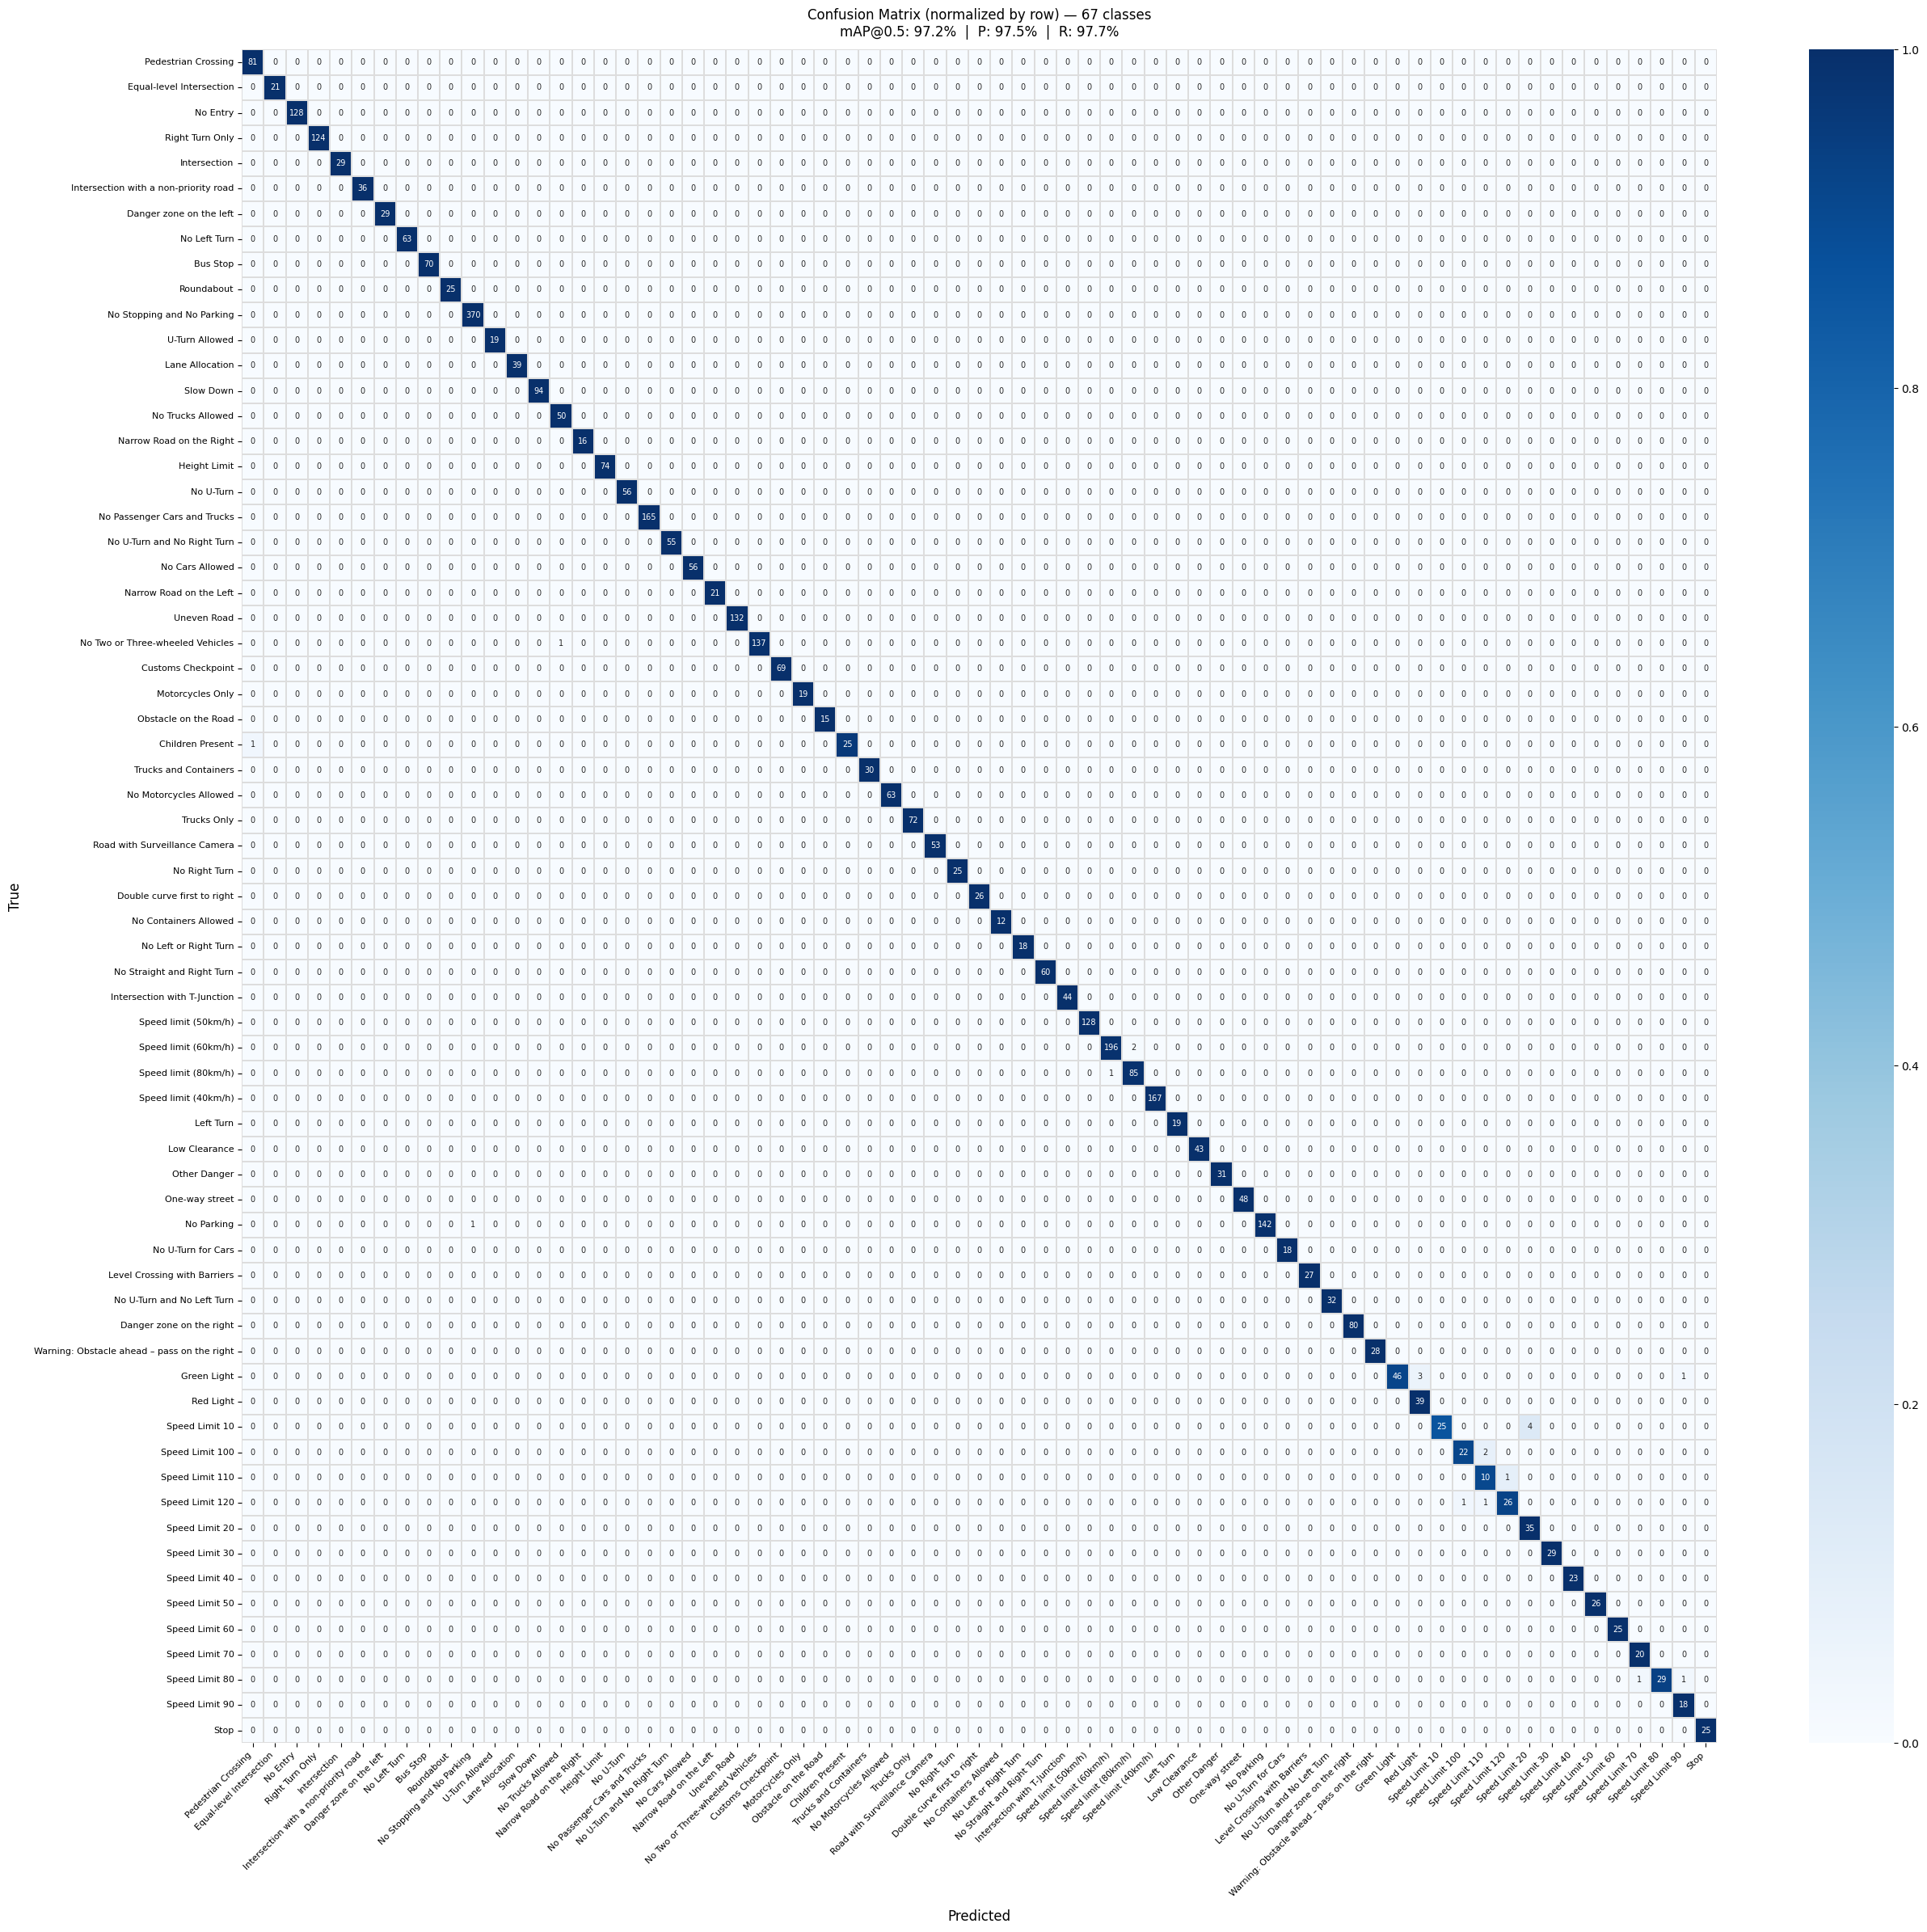

✅ Confusion matrix lưu tại: /kaggle/working/confusion_matrix_fixed.png


In [79]:
# ============================================================
# BƯỚC 3: Confusion matrix từ results (YOLO tính sẵn)
# ============================================================
# YOLO lưu confusion matrix tại results.confusion_matrix.matrix
cm_raw = results.confusion_matrix.matrix  # shape: (nc+1, nc+1) bao gồm background
 
# Bỏ hàng/cột background (index cuối)
nc = len(class_names)
cm = cm_raw[:nc, :nc].astype(int)
 
# Normalize theo hàng (true class)
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(float), row_sum,
                    out=np.zeros_like(cm, dtype=float),
                    where=row_sum != 0)
 
# Chỉ lấy các class có GT > 0 để tránh hàng trống
has_gt   = row_sum.flatten() > 0
cls_idx  = [i for i in range(nc) if has_gt[i]]
cls_lbls = [class_names[i] for i in cls_idx]
 
cm_show      = cm[np.ix_(cls_idx, cls_idx)]
cm_norm_show = cm_norm[np.ix_(cls_idx, cls_idx)]
 
print(f"\nVẽ confusion matrix: {len(cls_idx)} classes có GT > 0")
 
fig, ax = plt.subplots(figsize=(26, 24), facecolor="white")
sns.heatmap(
    cm_norm_show,
    annot=cm_show,
    fmt="d",
    xticklabels=cls_lbls,
    yticklabels=cls_lbls,
    cmap="Blues",
    ax=ax,
    annot_kws={"size": 7},
    vmin=0, vmax=1,
    linewidths=0.3,
    linecolor="#dddddd",
)
ax.set_xlabel("Predicted", fontsize=12, labelpad=10)
ax.set_ylabel("True",      fontsize=12, labelpad=10)
ax.set_title(
    f"Confusion Matrix (normalized by row) — {len(cls_idx)} classes\n"
    f"mAP@0.5: {results.box.map50*100:.1f}%  |  "
    f"P: {results.box.mp*100:.1f}%  |  R: {results.box.mr*100:.1f}%",
    fontsize=12, pad=12
)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_fixed.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix lưu tại: /kaggle/working/confusion_matrix_fixed.png")

/tmp/ipykernel_57/1704119367.py:64: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1704119367.py:64: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1704119367.py:64: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1704119367.py:65: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/perclass_analysis_fixed.png",
/tmp/ipykernel_57/1704119367.py:65: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/perclass_analysis_fixed.png",
/tmp/ipykernel_57/1704119367.py:65: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/perclass_analysis_fixed.png",
/usr/local/lib/python3.12/dist

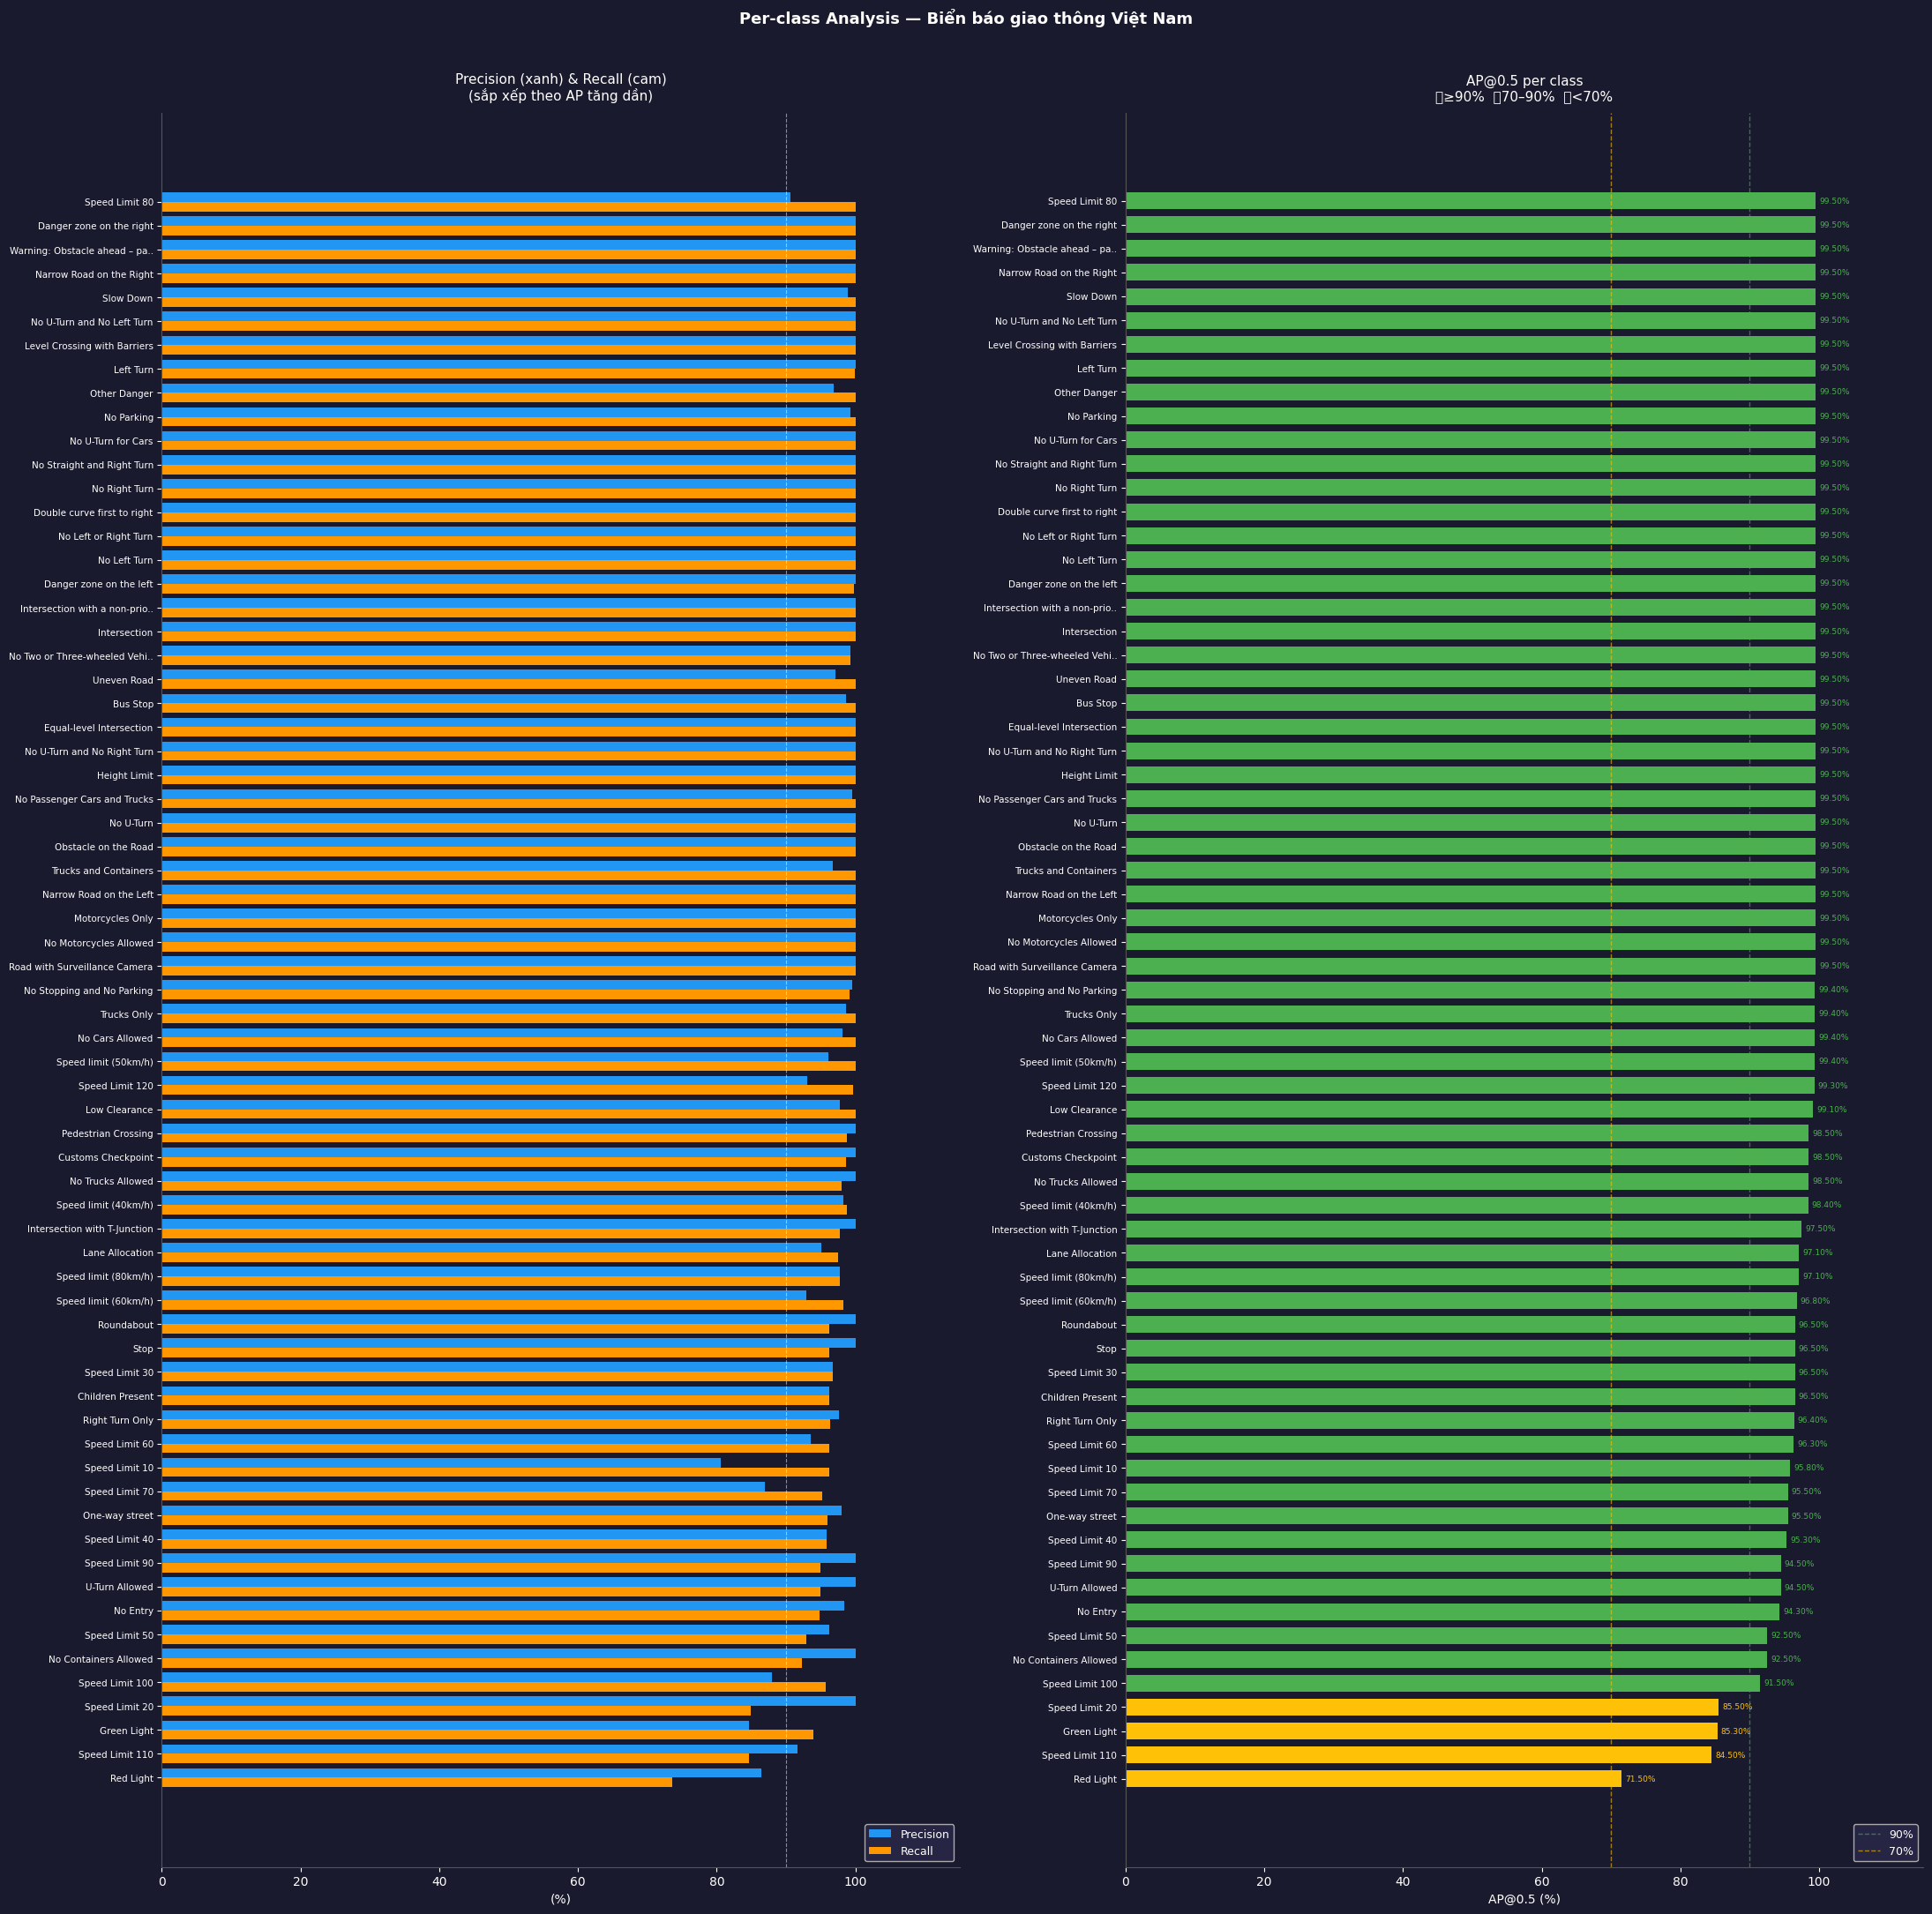

✅ Per-class chart lưu tại: /kaggle/working/perclass_analysis_fixed.png


In [80]:
# ============================================================
# BƯỚC 4: Bar chart AP@0.5 per class (2 panel)
# ============================================================
fig, axes = plt.subplots(1, 2,
                          figsize=(22, max(8, len(df) * 0.32)),
                          facecolor="#1a1a2e")
 
short_names = [n[:28] + ".." if len(n) > 30 else n for n in df["Class"].tolist()]
y_pos = list(range(len(df)))
 
# Panel trái: P và R stacked
ax1 = axes[0]
ax1.set_facecolor("#1a1a2e")
ax1.barh(y_pos, df["P (%)"], color="#2196F3", label="Precision", height=0.4,
         align="edge")
ax1.barh([y - 0.4 for y in y_pos], df["R (%)"], color="#FF9800",
         label="Recall", height=0.4, align="edge")
ax1.axvline(x=90, color="white", linestyle="--", linewidth=0.8, alpha=0.5)
ax1.set_xlim(0, 115)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(short_names, fontsize=7.5, color="white")
ax1.set_xlabel("(%)", color="white", fontsize=10)
ax1.set_title("Precision (xanh) & Recall (cam)\n(sắp xếp theo AP tăng dần)",
              color="white", fontsize=11, pad=10)
ax1.tick_params(colors="white")
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
for spine in ["bottom", "left"]:
    ax1.spines[spine].set_color("#555")
ax1.legend(loc="lower right", fontsize=9,
           facecolor="#2a2a4a", labelcolor="white")
 
# Panel phải: AP@0.5
ax2 = axes[1]
ax2.set_facecolor("#1a1a2e")
colors = ["#4CAF50" if a >= 90 else ("#FFC107" if a >= 70 else "#F44336")
          for a in df["AP@0.5"]]
ax2.barh(y_pos, df["AP@0.5"], color=colors, height=0.7)
ax2.axvline(x=90, color="#4CAF50", linestyle="--", linewidth=1, alpha=0.6, label="90%")
ax2.axvline(x=70, color="#FFC107", linestyle="--", linewidth=1, alpha=0.6, label="70%")
ax2.set_xlim(0, 115)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(short_names, fontsize=7.5, color="white")
ax2.set_xlabel("AP@0.5 (%)", color="white", fontsize=10)
ax2.set_title("AP@0.5 per class\n🟢≥90%  🟡70–90%  🔴<70%",
              color="white", fontsize=11, pad=10)
ax2.tick_params(colors="white")
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
for spine in ["bottom", "left"]:
    ax2.spines[spine].set_color("#555")
ax2.legend(loc="lower right", fontsize=9,
           facecolor="#2a2a4a", labelcolor="white")
 
# Ghi số AP lên bar
for i, (_, r) in enumerate(df.iterrows()):
    ax2.text(r["AP@0.5"] + 0.5, i, f"{r['AP@0.5']:.2f}%",
             va="center", fontsize=6.5,
             color="#4CAF50" if r["AP@0.5"] >= 90
             else ("#FFC107" if r["AP@0.5"] >= 70 else "#F44336"))
 
fig.suptitle("Per-class Analysis — Biển báo giao thông Việt Nam",
             color="white", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_analysis_fixed.png",
            dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✅ Per-class chart lưu tại: /kaggle/working/perclass_analysis_fixed.png")

In [81]:
# ============================================================
# BƯỚC THỐNG KÊ: Các lớp có AP@0.5 trên 95%
# ============================================================
high_df = df[df["AP@0.5"] >= 95.0].copy().sort_values("ID").reset_index(drop=True)
total_classes = len(df)
num_high      = len(high_df)
percentage    = (num_high / total_classes) * 100 if total_classes > 0 else 0

model_name = os.path.basename(MODEL_PATH)  # ← lấy tên file từ path

print("\n" + "="*85)
print("🏆 THỐNG KÊ CÁC LỚP ĐẠT AP@0.5 ≥ 95%")
print("="*85)
print(f"🤖 Mô hình                  : {model_name}")
print(f"📊 Tổng số lớp đã đánh giá : {total_classes}")
print(f"✅ Số lớp đạt AP ≥ 95%      : {num_high}")
print(f"📈 Tỉ lệ                    : {percentage:.1f}%")
print("-" * 85)

if num_high > 0:
    print(f"{'ID':>4} | {'Tên Class':<45} | {'P (%)':>8} | {'R (%)':>8} | {'AP@0.5':>8}")
    print("-" * 85)
    for _, row in high_df.iterrows():
        print(f"{int(row['ID']):4d} | {row['Class']:<45} | "
              f"{row['P (%)']:7.2f}% | {row['R (%)']:7.2f}% | {row['AP@0.5']:7.2f}%")
else:
    print(" Hiện tại không có lớp nào đạt AP@0.5 ≥ 95% trên tập test.")

print("="*85)


🏆 THỐNG KÊ CÁC LỚP ĐẠT AP@0.5 ≥ 95%
🤖 Mô hình                  : best_yolov8l_newversion.pt
📊 Tổng số lớp đã đánh giá : 67
✅ Số lớp đạt AP ≥ 95%      : 57
📈 Tỉ lệ                    : 85.1%
-------------------------------------------------------------------------------------
  ID | Tên Class                                     |    P (%) |    R (%) |   AP@0.5
-------------------------------------------------------------------------------------
   0 | Pedestrian Crossing                           |  100.00% |   98.80% |   98.50%
   1 | Equal-level Intersection                      |  100.00% |  100.00% |   99.50%
   3 | Right Turn Only                               |   97.60% |   96.40% |   96.40%
   4 | Intersection                                  |  100.00% |  100.00% |   99.50%
   5 | Intersection with a non-priority road         |  100.00% |  100.00% |   99.50%
   6 | Danger zone on the left                       |  100.00% |   99.80% |   99.50%
   7 | No Left Turn                